---
## Block 1 Global Imports & Config

In [14]:
# Load Libs. needed across the pipeline
import pandas as pd                         # DataFrames / tabular data manipulation
import numpy as np                           # Numerical arrays & math operations
import matplotlib.pyplot as plt              # Base plotting library
import seaborn as sns                        # High-level statistical visualizations
import warnings
warnings.filterwarnings('ignore')            # Suppress non-critical warnings for clean output

# Sklearn: Preprocessing
from sklearn.preprocessing import (
    StandardScaler,
    LabelEncoder,
    OneHotEncoder
)
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    RandomizedSearchCV,
    StratifiedKFold
)
# Sklearn: Models
from sklearn.linear_model import LogisticRegression   # Baseline linear classifier
from sklearn.tree import DecisionTreeClassifier        # Single decision tree
from sklearn.ensemble import (
    RandomForestClassifier,      # Ensemble of decision trees (bagging)
    GradientBoostingClassifier,  # Sequential ensemble (gradient boosting)
    AdaBoostClassifier           # Adaptive boosting
)
from sklearn.svm import SVC
from xgboost import XGBClassifier

# Imbalanced Learning
from imblearn.over_sampling import SMOTE      # Synthetic Minority Over-sampling Technique

# Sklearn: Metrics
from sklearn.metrics import (
    accuracy_score,           # (TP+TN) / total — overall correctness
    f1_score,                 # Harmonic mean of precision & recall — handles class imbalance
    roc_auc_score,            # Area under ROC curve — ranking quality
    roc_curve,                # FPR vs TPR at different thresholds
    confusion_matrix,         # TP/FP/TN/FN counts
    ConfusionMatrixDisplay,   # Pretty confusion matrix plot
    classification_report,    # Per-class precision, recall, F1
    precision_score,
    recall_score
)

# Global Plot Configs
plt.rcParams['figure.dpi'] = 100
sns.set_theme(style='whitegrid', palette='muted')
print('✅ All libraries loaded successfully')
print(f'   pandas {pd.__version__} | numpy {np.__version__}')

✅ All libraries loaded successfully
   pandas 3.0.0 | numpy 2.1.3


---
## Block 2: Data Loading & EDA

In [15]:
df = pd.read_csv('Bank_Churn_Modelling.csv')

print ('='*80)
print (f'Data set Shape: {df.shape[0]:,} rows X {df.shape[1]:,} columns')
print ('='*80)

# For missing data use this function
def missing_report(dataframe):
    """Returns a DataFrame showing count + % of missing values per column.
    Only shows columns that actually have missing data."""
    missing = dataframe.isnull().sum()
    missing_pct = (missing / len(dataframe) * 100).round(2)
    report = pd.DataFrame({'Count': missing, 'Percentage_%': missing_pct})
    report = report[report['Count'] > 0].sort_values('Percentage_%', ascending=False)
    if report.empty:
        print('✅ No missing values found!')
    return report

print (missing_report(df))
print ('='*80)

print(df.describe().T.to_string())
print ('='*80)



Data set Shape: 10,000 rows X 14 columns
✅ No missing values found!
Empty DataFrame
Columns: [Count, Percentage_%]
Index: []
                   count          mean           std          min          25%           50%           75%          max
RowNumber        10000.0  5.000500e+03   2886.895680         1.00      2500.75  5.000500e+03  7.500250e+03     10000.00
CustomerId       10000.0  1.569094e+07  71936.186123  15565701.00  15628528.25  1.569074e+07  1.575323e+07  15815690.00
CreditScore      10000.0  6.505288e+02     96.653299       350.00       584.00  6.520000e+02  7.180000e+02       850.00
Age              10000.0  3.892180e+01     10.487806        18.00        32.00  3.700000e+01  4.400000e+01        92.00
Tenure           10000.0  5.012800e+00      2.892174         0.00         3.00  5.000000e+00  7.000000e+00        10.00
Balance          10000.0  7.648589e+04  62397.405202         0.00         0.00  9.719854e+04  1.276442e+05    250898.09
NumOfProducts    10000.0  1.530200e

---
## Block 3: cont. EDA

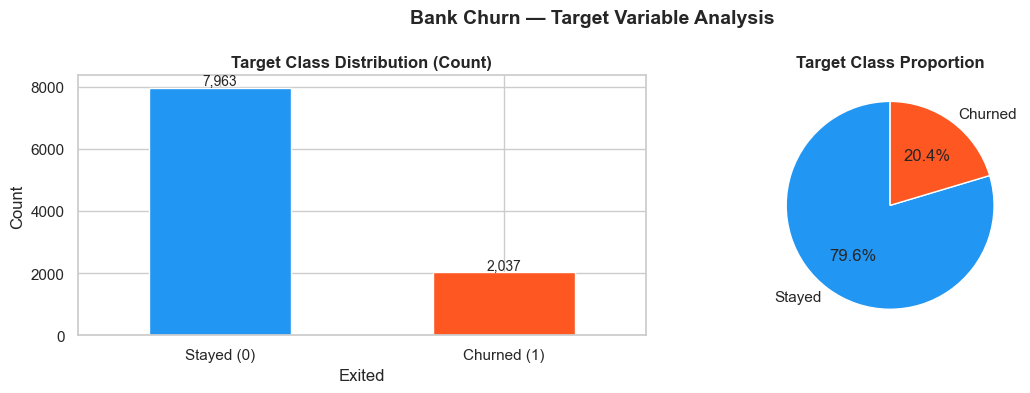

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart of counts
df['Exited'].value_counts().plot(kind='bar', ax=axes[0], color=['#2196F3','#FF5722'],
                                  edgecolor='white', rot=0)
axes[0].set_title('Target Class Distribution (Count)', fontsize=12, fontweight='bold')
axes[0].set_xticklabels(['Stayed (0)', 'Churned (1)'])
axes[0].set_ylabel('Count')
for bar in axes[0].patches:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 80,
                 f'{int(bar.get_height()):,}', ha='center', fontsize=10)

# Pie chart of proportions
axes[1].pie(df['Exited'].value_counts(), labels=['Stayed','Churned'],
            autopct='%1.1f%%', colors=['#2196F3','#FF5722'], startangle=90)
axes[1].set_title('Target Class Proportion', fontsize=12, fontweight='bold')

plt.suptitle('Bank Churn — Target Variable Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Insight: Aprox 80%% stayed in the bank --> imblance Data need SMOTE later

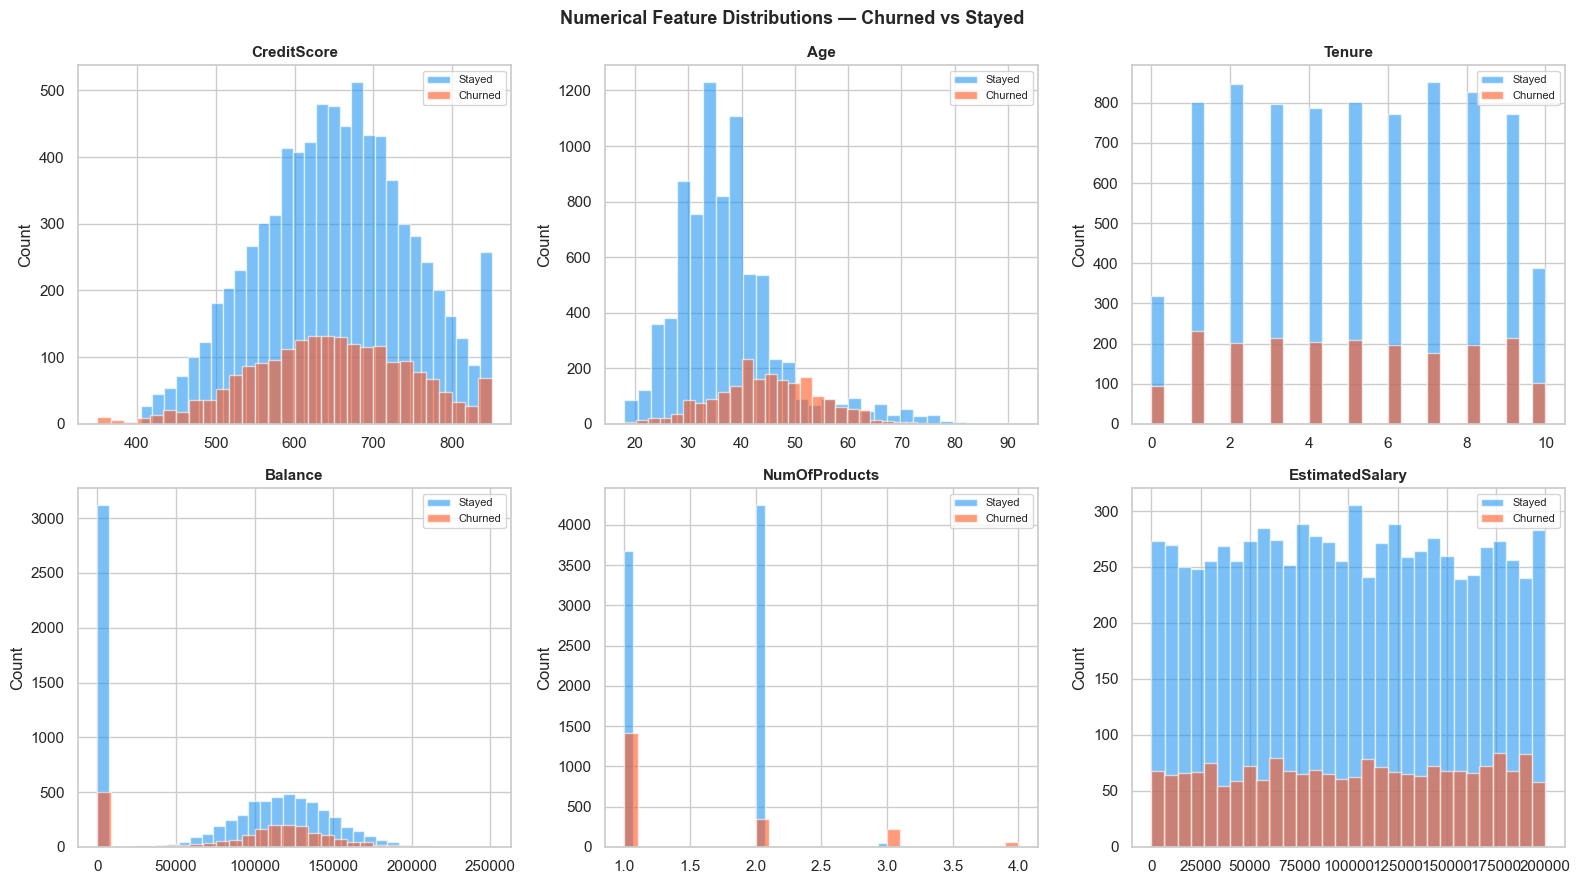

In [17]:
# ── 3.2  Numerical feature distributions ─────────────────────────────
num_feats = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary']
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for ax, col in zip(axes, num_feats):
    # Split by target to see if distribution differs between churned & not
    df[df['Exited']==0][col].hist(ax=ax, alpha=0.6, color='#2196F3', bins=30, label='Stayed')
    df[df['Exited']==1][col].hist(ax=ax, alpha=0.6, color='#FF5722', bins=30, label='Churned')
    ax.set_title(f'{col}', fontsize=11, fontweight='bold')
    ax.legend(fontsize=8)
    ax.set_ylabel('Count')

plt.suptitle('Numerical Feature Distributions — Churned vs Stayed', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Insights:
# Most of People of Age [20,40] Stayed
# People with 3,4 Product number churned --> bad sales?

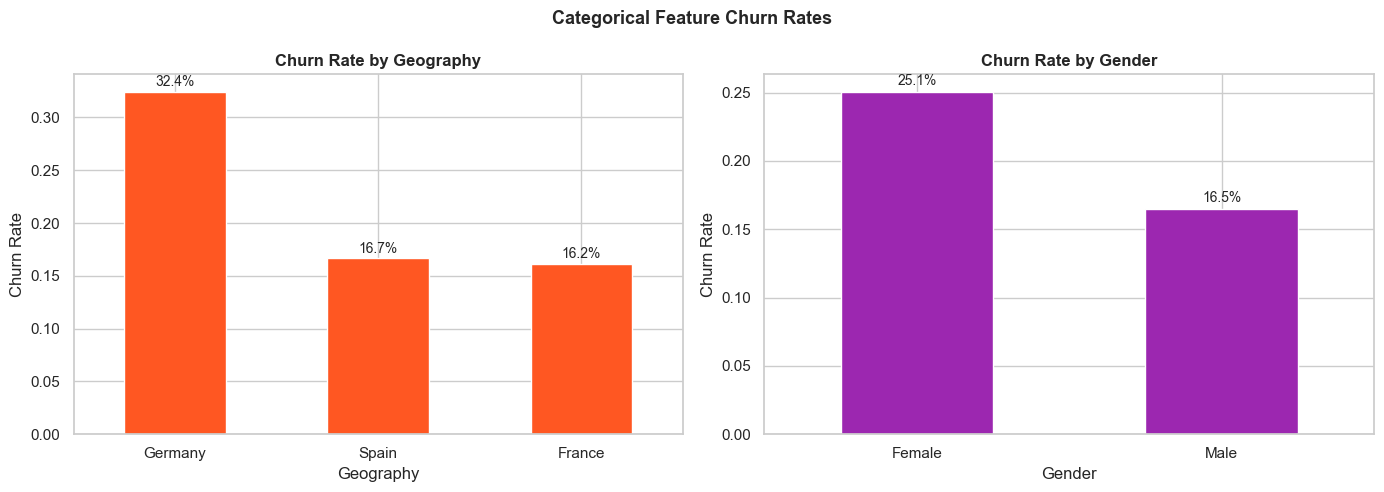

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Geography churn rate
geo_churn = df.groupby('Geography')['Exited'].mean().sort_values(ascending=False)
geo_churn.plot(kind='bar', ax=axes[0], color='#FF5722', edgecolor='white', rot=0)
axes[0].set_title('Churn Rate by Geography', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Churn Rate')
axes[0].set_xlabel('Geography')
for bar in axes[0].patches:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{bar.get_height():.1%}', ha='center', fontsize=10)

# Gender churn rate
gender_churn = df.groupby('Gender')['Exited'].mean().sort_values(ascending=False)
gender_churn.plot(kind='bar', ax=axes[1], color='#9C27B0', edgecolor='white', rot=0)
axes[1].set_title('Churn Rate by Gender', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Churn Rate')
for bar in axes[1].patches:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{bar.get_height():.1%}', ha='center', fontsize=10)

plt.suptitle('Categorical Feature Churn Rates', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
# Insights:
# Germany has high churn rates
# Females are more likely to churn

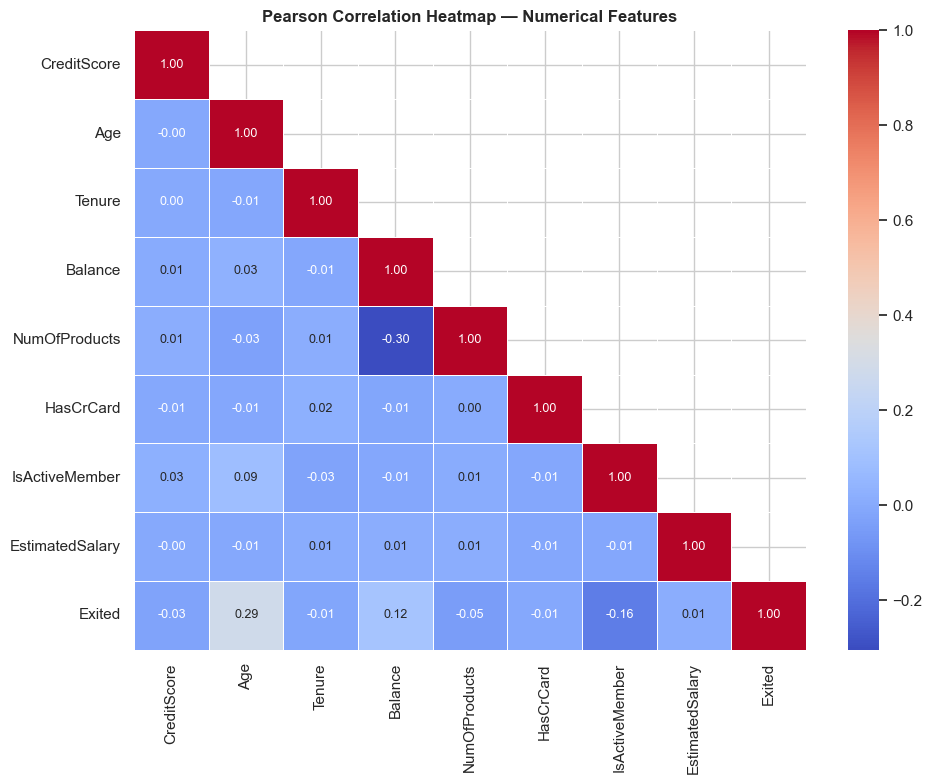

In [19]:
# Correlation Map
num_only = df.select_dtypes(include='number').drop(['RowNumber','CustomerId'], axis=1)
corr = num_only.corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)  # upper triangle → hide to show lower only
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', ax=ax,
            mask=mask, linewidths=0.5, annot_kws={'size': 9})
ax.set_title('Pearson Correlation Heatmap — Numerical Features', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()
# Insights:
# Age is the highest correlated with Exited
# isActiveMember logically correlates with exited Thinking of dropping that feature entirly

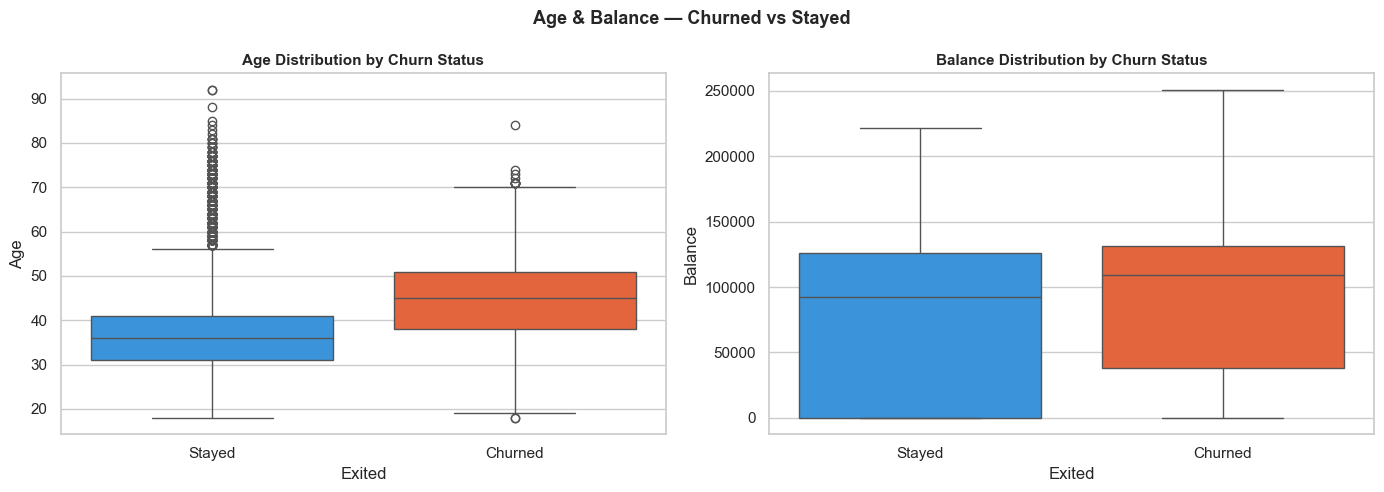

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, col in zip(axes, ['Age', 'Balance']):
    sns.boxplot(x='Exited', y=col, data=df, ax=ax, palette={'0':'#2196F3', '1':'#FF5722'})
    ax.set_xticklabels(['Stayed', 'Churned'])
    ax.set_title(f'{col} Distribution by Churn Status', fontsize=11, fontweight='bold')

plt.suptitle('Age & Balance — Churned vs Stayed', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Drop Irrelevant Columns & define Features (x), Target (y)

In [21]:
# PURPOSE: Remove columns that are identifiers (no predictive power),
#          then define the feature matrix X and target vector y.
# WHY DROP: RowNumber, CustomerId, Surname are administrative IDs.
#   - Including them would cause data leakage: the model might memorize IDs
#     not learn patterns. They generalize to ZERO on new customers.
#       isActiveMember --> logically if one is active in the bank then they wont leave it 

COLS_TO_DROP = ['RowNumber', 'CustomerId', 'Surname', 'IsActiveMember']
df_clean = df.drop(columns=COLS_TO_DROP)

TARGET = 'Exited'
X = df_clean.drop(TARGET, axis=1)
y = df_clean[TARGET]         # 0--> Stayed, 1--> Churned
print(f'\nX shape: {X.shape}  |  y shape: {y.shape}')
print(f'Target distribution:  0={y.value_counts()[0]}  |  1={y.value_counts()[1]}')



X shape: (10000, 9)  |  y shape: (10000,)
Target distribution:  0=7963  |  1=2037


---
## Block 5: Train & Validation & Test Also using random_state = 42 for reproductiblity

In [22]:
# Train Data: 60%, Validation Data: 20%, Test Data: 20%
X_temp ,X_test, y_temp, y_test = train_test_split(
    X,
    y,
    test_size= 0.2, # Test = 20% of Data
    stratify=y,
    random_state= 42
)
X_train ,X_val, y_train, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size= 0.25, # Validation = 20% of Data
    stratify= y_temp,
    random_state= 42
)

# DONT USE THE TEST DATA AT ALL UNTIL THE END
print ('DONT USE THE TEST DATA AT ALL UNTIL THE END')
print ("\nTest Data is now Locked")

DONT USE THE TEST DATA AT ALL UNTIL THE END

Test Data is now Locked


---
## Block 6: Data Preprocessing

In [ ]:
# Use Pipeline to encode data and fit one time
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# Define Columns
numeric_cols = [
    'CreditScore',
    'Age',
    'Tenure',
    'Balance',
    'NumOfProducts',
    'EstimatedSalary'
]

binary_cols = ['HasCrCard']

nominal_cols = ['Geography', 'Gender']

# Preprocessor WITH scaling
preprocessor1 = ColumnTransformer(
    transformers=[
        (
            'num',
            StandardScaler(),
            numeric_cols
        ),
        (
            'ohe',
            OneHotEncoder(
                drop='first',
                handle_unknown='ignore',
                sparse_output=False
            ),
            nominal_cols
        )
    ],
    remainder='passthrough'
)

# Preprocessor WITHOUT scaling
preprocessor2 = ColumnTransformer(
    transformers=[
        (
            'ohe',
            OneHotEncoder(
                drop='first',
                handle_unknown='ignore',
                sparse_output=False
            ),
            nominal_cols
        )
    ],
    remainder='passthrough'
)

# Proc1 → WITH scaling
X_train_proc1 = preprocessor1.fit_transform(X_train)
X_val_proc1   = preprocessor1.transform(X_val)
X_test_proc1  = preprocessor1.transform(X_test)

# Proc2 → WITHOUT scaling
X_train_proc2 = preprocessor2.fit_transform(X_train)
X_val_proc2   = preprocessor2.transform(X_val)
X_test_proc2  = preprocessor2.transform(X_test)

print('✅ Preprocessing completed without data leakage')

print('\nShapes:')
print('X_train_proc1:', X_train_proc1.shape)
print('X_val_proc1:  ', X_val_proc1.shape)
print('X_test_proc1: ', X_test_proc1.shape)

✅ Preprocessing completed without data leakage

Shapes:
X_train_proc1: (6000, 10)
X_val_proc1:   (2000, 10)
X_test_proc1:  (2000, 10)


---
## Block 7: Handling Imbalanced Data with SMOTE

In [24]:
SM = SMOTE(random_state=42)

X_train_smote1, y_train_smote1 = SM.fit_resample(X_train_proc1, y_train)
X_train_smote2, y_train_smote2 = SM.fit_resample(X_train_proc2, y_train)

# Smote_counts1 for X_train_smote1, y_train_smote1
smote_counts1 = pd.Series(y_train_smote1).value_counts()
print(f'  Stayed (0):  {smote_counts1[0]:,}  ({smote_counts1[0]/len(y_train_smote1)*100:.1f}%)')
print(f'  Churned (1): {smote_counts1[1]:,}  ({smote_counts1[1]/len(y_train_smote1)*100:.1f}%)')
print(f'  Total rows after SMOTE: {len(X_train_smote1):,}')
print('  ✅ Classes are now balanced — fair training for both classes')
print('  🔒 Validation and test remain UNCHANGED (real-world distribution)')

# Smote_counts2 for X_train_smote2, y_train_smote2
print ("="*80)
smote_counts2 = pd.Series(y_train_smote2).value_counts()
print(f'  Stayed (0):  {smote_counts2[0]:,}  ({smote_counts2[0]/len(y_train_smote2)*100:.1f}%)')
print(f'  Churned (1): {smote_counts2[1]:,}  ({smote_counts2[1]/len(y_train_smote2)*100:.1f}%)')
print(f'  Total rows after SMOTE: {len(X_train_smote1):,}')
print('  ✅ Classes are now balanced — fair training for both classes')
print('  🔒 Validation and test remain UNCHANGED (real-world distribution)')

  Stayed (0):  4,777  (50.0%)
  Churned (1): 4,777  (50.0%)
  Total rows after SMOTE: 9,554
  ✅ Classes are now balanced — fair training for both classes
  🔒 Validation and test remain UNCHANGED (real-world distribution)
  Stayed (0):  4,777  (50.0%)
  Churned (1): 4,777  (50.0%)
  Total rows after SMOTE: 9,554
  ✅ Classes are now balanced — fair training for both classes
  🔒 Validation and test remain UNCHANGED (real-world distribution)


---
## Block 8: Model Comparasons

In [25]:
# WHY MULTIPLE MODELS:
#   - Logistic Regression: fast, interpretable, good baseline
#   - Random Forest: robust ensemble, handles non-linearity, gives feature importance
#   - XGBoost / LGBM: usually best performance on tabular data
#   - Decision Tree: interpretable, fast, prone to overfitting
#
# Using Validation Sets only Not Test 

import time

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
    'Decision Tree':       DecisionTreeClassifier(max_depth=6, random_state=42, class_weight='balanced'),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced', n_jobs=-1),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=100, random_state=42),
    'XGBoost':  XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss', verbosity=0,scale_pos_weight=4)  # handles imbalance
}
results =[]

for name, model in models.items():
    start = time.time()
    model.fit(X_train_smote1, y_train_smote1)
    elapsed = time.time() - start

    y_val_prid1 = model.predict(X_val_proc1)
    y_val_pred1_prob = model.predict_proba(X_val_proc1)[:, 1] if hasattr(model, 'predict_proba') else None


    acc     = accuracy_score(y_val, y_val_prid1)
    f1      = f1_score(y_val, y_val_prid1, average='binary')
    f1_mac  = f1_score(y_val, y_val_prid1, average='macro')
    recall  = recall_score(y_val, y_val_prid1)
    prec    = precision_score(y_val, y_val_prid1)
    auc     = roc_auc_score(y_val, y_val_pred1_prob) if y_val_pred1_prob is not None else None


    results.append({
        'Model':      name,
        'Accuracy':   round(acc, 4),
        'F1 (Binary)':round(f1, 4),
        'F1 (Macro)': round(f1_mac, 4),
        'Recall':     round(recall, 4),
        'Precision':  round(prec, 4),
        'ROC-AUC':    round(auc, 4) if auc is not None else 'N/A',
        'Train (s)':  round(elapsed, 2)
    })
    auc_str = f'{auc:.4f}' if auc is not None else 'N/A'
    print(f'  ✅ {name:<25} | F1={f1:.4f} | AUC={auc_str} | {elapsed:.2f}s')

# Results Data Frame
results_df = pd.DataFrame(results).sort_values('ROC-AUC', ascending=False)
print('\n' + '='*80)
print('  VALIDATION SET PERFORMANCE COMPARISON')
print('='*80)
print(results_df.to_string(index=False))

# Best Model on Smote1 
best_model_name = results_df.iloc[0]['Model']
best_model = models[best_model_name]
print(f'\n🏆 Best model by ROC-AUC: {best_model_name}')
print('='*80)
print('='*80)
print('='*80)



results =[]

for name, model in models.items():
    start = time.time()
    model.fit(X_train_smote2, y_train_smote2)
    elapsed = time.time() - start

    y_val_prid2 = model.predict(X_val_proc2)
    y_val_pred2_prob = model.predict_proba(X_val_proc2)[:, 1] if hasattr(model, 'predict_proba') else None

    acc     = accuracy_score(y_val, y_val_prid2)
    f1      = f1_score(y_val, y_val_prid2, average='binary')
    f1_mac  = f1_score(y_val, y_val_prid2, average='macro')
    recall  = recall_score(y_val, y_val_prid2)
    prec    = precision_score(y_val, y_val_prid2)
    auc     = roc_auc_score(y_val, y_val_pred2_prob) if y_val_pred2_prob is not None else None


    results.append({
        'Model':      name,
        'Accuracy':   round(acc, 4),
        'F1 (Binary)':round(f1, 4),
        'F1 (Macro)': round(f1_mac, 4),
        'Recall':     round(recall, 4),
        'Precision':  round(prec, 4),
        'ROC-AUC':    round(auc, 4) if auc is not None else 'N/A',
        'Train (s)':  round(elapsed, 2)
    })
    auc_str = f'{auc:.4f}' if auc is not None else 'N/A'
    print(f'  ✅ {name:<25} | F1={f1:.4f} | AUC={auc_str} | {elapsed:.2f}s')

# Results Data Frame
results_df = pd.DataFrame(results).sort_values('ROC-AUC', ascending=False)
print('\n' + '='*80)
print('  VALIDATION SET PERFORMANCE COMPARISON')
print('='*80)
print(results_df.to_string(index=False))

# Best Model on Smote2 
best_model_name = results_df.iloc[0]['Model']
best_model = models[best_model_name]
print(f'\n🏆 Best model by ROC-AUC: {best_model_name}')
print('='*80)

# Insights:
# it is better to use Scaled data so i will use The data 1 (That has the Scaling) not 2( without scaling) 
# Gradient boost has better ROC but Random Forest has better F1, So i wanna tune the model with Grid search on both

  ✅ Logistic Regression       | F1=0.4857 | AUC=0.7540 | 0.89s
  ✅ Decision Tree             | F1=0.5499 | AUC=0.8177 | 0.04s
  ✅ Random Forest             | F1=0.5690 | AUC=0.8391 | 0.44s
  ✅ Gradient Boosting         | F1=0.5789 | AUC=0.8442 | 1.76s
  ✅ XGBoost                   | F1=0.5702 | AUC=0.8155 | 0.31s

  VALIDATION SET PERFORMANCE COMPARISON
              Model  Accuracy  F1 (Binary)  F1 (Macro)  Recall  Precision  ROC-AUC  Train (s)
  Gradient Boosting    0.8465       0.5789      0.7425  0.5184     0.6553   0.8442       1.76
      Random Forest    0.8470       0.5690      0.7380  0.4963     0.6667   0.8391       0.44
      Decision Tree    0.8240       0.5499      0.7202  0.5283     0.5733   0.8177       0.04
            XGBoost    0.8055       0.5702      0.7222  0.6339     0.5181   0.8155       0.31
Logistic Regression    0.7035       0.4857      0.6387  0.6880     0.3753   0.7540       0.89

🏆 Best model by ROC-AUC: Gradient Boosting
  ✅ Logistic Regression       | F1=0

---
## Block 9: HyperParamters Tuning with GridSearch

In [26]:
# WHY GridSearchCV WITH cv: Uses k-fold cross-validation on X_train_smote
#   to estimate generalization — more robust than a single val split.

param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [8, 10, 12],      # Forced limit
    'min_samples_leaf': [10, 20],  # Prevents memorizing noise
    'max_features': ['sqrt']
}

param_grid_GB = {
    'n_estimators':   [100, 200],
    'learning_rate':  [0.01, 0.1, 0.2], 
    'max_depth':      [3, 5, 8],        # GB usually needs shallower trees
    'subsample':      [0.8, 1.0],       
    'min_samples_leaf': [1, 5]
}

tuned_model1 = RandomForestClassifier(random_state=42, class_weight='balanced', n_jobs=-1)
tuned_model2 = GradientBoostingClassifier(random_state=42)

# Stratified to keep class balance in each fold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
final_comparison = []

grid_search = GridSearchCV(
    estimator=tuned_model1,
    param_grid=param_grid_rf,
    n_jobs=-1,
    cv= cv,
    verbose= 1,
    scoring= 'roc_auc'
)
print('🔍 Running GridSearchCV — this may take a few minutes...')
grid_search.fit(X_train_smote1, y_train_smote1)

print(f'\n✅ Best parameters: {grid_search.best_params_}')
print(f'   Best cross-val ROC-AUC: {grid_search.best_score_:.4f}')

best_rf = grid_search.best_estimator_
y_val_pred_tuned = best_rf.predict(X_val_proc1)
y_val_prob_tuned = best_rf.predict_proba(X_val_proc1)[:, 1]

print(f'\n  Validation ROC-AUC (tuned RF): {roc_auc_score(y_val, y_val_prob_tuned):.4f}')
print(f'  Validation F1 (binary):         {f1_score(y_val, y_val_pred_tuned):.4f}')
print(f'  Validation Accuracy:             {accuracy_score(y_val, y_val_pred_tuned):.4f}')

print('='*80)

grid_search = GridSearchCV(
    estimator=tuned_model2,
    param_grid=param_grid_GB,
    n_jobs=-1,
    cv= cv,
    verbose= 1,
    scoring= 'roc_auc'
)
print('🔍 Running GradientBoosting — this may take a few minutes...')
grid_search.fit(X_train_smote1, y_train_smote1)

print(f'\n✅ Best parameters: {grid_search.best_params_}')
print(f'   Best cross-val ROC-AUC: {grid_search.best_score_:.4f}')

best_GB = grid_search.best_estimator_
y_val_pred_tuned = best_rf.predict(X_val_proc1)
y_val_prob_tuned = best_rf.predict_proba(X_val_proc1)[:, 1]

print(f'\n  Validation ROC-AUC (tuned GB): {roc_auc_score(y_val, y_val_prob_tuned):.4f}')
print(f'  Validation F1 (binary):         {f1_score(y_val, y_val_pred_tuned):.4f}')
print(f'  Validation Accuracy:             {accuracy_score(y_val, y_val_pred_tuned):.4f}')

# Insights:
# Random Forest is a better model with a better f1 score so we will use it it with the best params
# for one more test on the test set

🔍 Running GridSearchCV — this may take a few minutes...
Fitting 5 folds for each of 12 candidates, totalling 60 fits

✅ Best parameters: {'max_depth': 12, 'max_features': 'sqrt', 'min_samples_leaf': 10, 'n_estimators': 200}
   Best cross-val ROC-AUC: 0.9576

  Validation ROC-AUC (tuned RF): 0.8454
  Validation F1 (binary):         0.5837
  Validation Accuracy:             0.8495
🔍 Running GradientBoosting — this may take a few minutes...
Fitting 5 folds for each of 72 candidates, totalling 360 fits

✅ Best parameters: {'learning_rate': 0.1, 'max_depth': 8, 'min_samples_leaf': 5, 'n_estimators': 100, 'subsample': 0.8}
   Best cross-val ROC-AUC: 0.9606

  Validation ROC-AUC (tuned GB): 0.8454
  Validation F1 (binary):         0.5837
  Validation Accuracy:             0.8495


---
## Block 10: final test set Eval.

   FINAL TEST SET PERFORMANCE (Tuned Random Forest)
  Accuracy: 0.8515
  F1 (Binary): 0.5970
  F1 (Macro): 0.7530
  Recall: 0.5405
  Precision: 0.6667
  ROC-AUC: 0.8481
Classification report

              precision    recall  f1-score   support

      Stayed       0.89      0.93      0.91      1593
     Churned       0.67      0.54      0.60       407

    accuracy                           0.85      2000
   macro avg       0.78      0.74      0.75      2000
weighted avg       0.84      0.85      0.85      2000



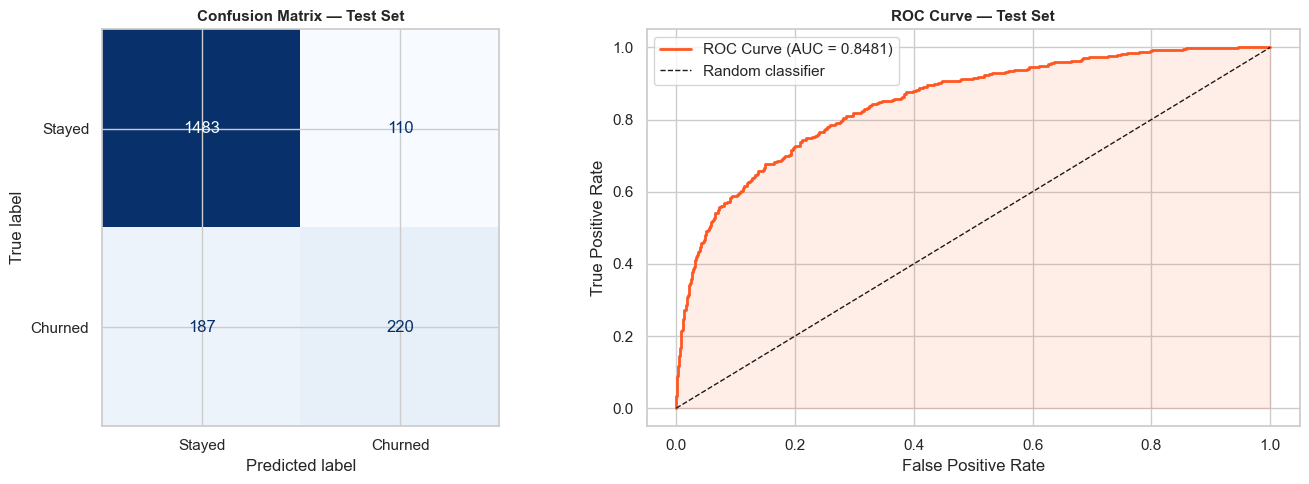

In [27]:
# WHY ONLY ONCE: This is the true unbiased estimate of real-world performance.
#   If you peek at test results and retune — that's data leakage!

# METRICS USED:
#   Accuracy:   Overall correctness (less informative with imbalance)
#   F1 Binary:  Balance of catching churners vs false alarms
#   ROC-AUC:    Ranking quality — does model score churners higher than stayers?
#   Recall:     Of all actual churners, what % did we catch?  (Critical for bank!)
#   Precision:  Of flagged churners, what % actually churned? (Cost of intervention)

y_test_pred = best_rf.predict(X_test_proc1)
y_test_prob = best_rf.predict_proba(X_test_proc1)[:, 1]

test_metrics = {
    'Accuracy':   accuracy_score(y_test, y_test_pred),
    'F1 (Binary)':f1_score(y_test, y_test_pred),
    'F1 (Macro)': f1_score(y_test, y_test_pred, average='macro'),
    'Recall':     recall_score(y_test, y_test_pred),
    'Precision':  precision_score(y_test, y_test_pred),
    'ROC-AUC':    roc_auc_score(y_test, y_test_prob),
}

print('=' * 80)
print('   FINAL TEST SET PERFORMANCE (Tuned Random Forest)')
print('=' * 80)
for metric, val in test_metrics.items():
    print(f'  {metric}: {val:.4f}')

# full Classification report 
print ('Classification report\n')
report = classification_report(y_test, y_test_pred, target_names=['Stayed', 'Churned'])
print(report)


# Confusion matrix 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_test, y_test_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['Stayed','Churned'])
disp.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Confusion Matrix — Test Set', fontsize=11, fontweight='bold')

# ROC
fpr, tpr, _ = roc_curve(y_test, y_test_prob)
axes[1].plot(fpr, tpr, color='#FF5722', lw=2,
             label=f'ROC Curve (AUC = {test_metrics["ROC-AUC"]:.4f})')
axes[1].plot([0,1],[0,1], 'k--', lw=1, label='Random classifier')
axes[1].fill_between(fpr, tpr, alpha=0.1, color='#FF5722')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve — Test Set', fontsize=11, fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()



---
## Block 11: Feature Importance

Top 10 Most Important Features for Churn Prediction:
                   Feature  Importance
  remainder__NumOfProducts    0.267119
            remainder__Age    0.240761
          ohe__Gender_Male    0.145205
    ohe__Geography_Germany    0.111460
        remainder__Balance    0.060688
      ohe__Geography_Spain    0.055725
      remainder__HasCrCard    0.045297
remainder__EstimatedSalary    0.028762
         remainder__Tenure    0.023059
    remainder__CreditScore    0.021923


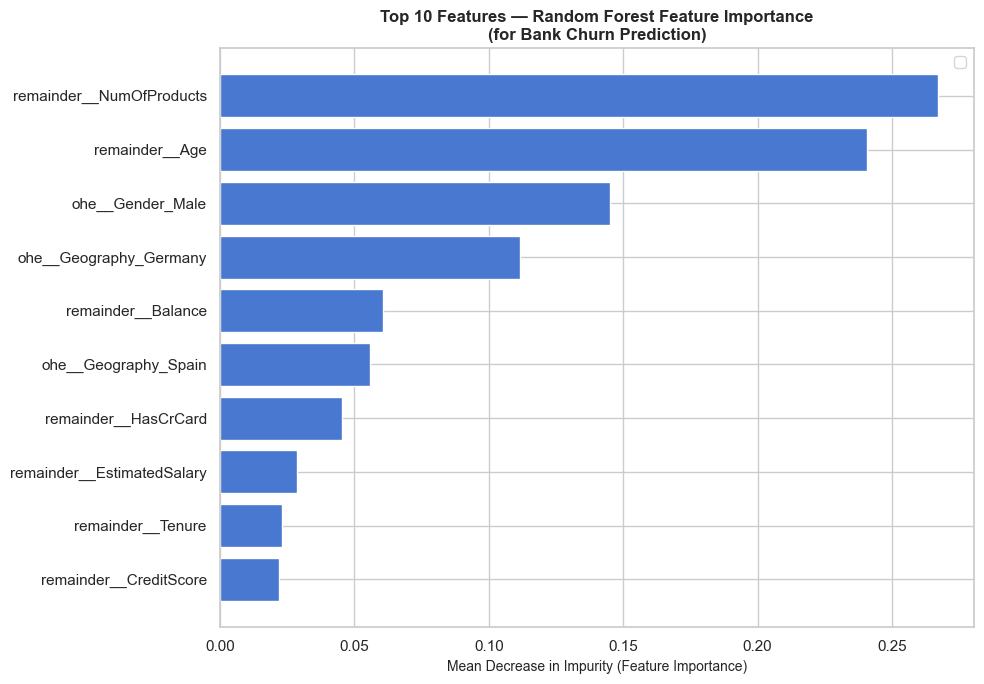


🔎 Overfitting / Underfitting Analysis:
  Train F1:      0.9154
  Validation F1: 0.5837
  Test F1:       0.5970
  ⚠️  Gap = 0.3184 > 0.10 → Possible OVERFITTING — consider more regularization


In [28]:
all_feature_names = preprocessor1.get_feature_names_out()
feature_importances = best_rf.feature_importances_
feat_imp_df = pd.DataFrame({
    'Feature':    all_feature_names,
    'Importance': feature_importances
}).sort_values('Importance', ascending=False).reset_index(drop=True)

print('Top 10 Most Important Features for Churn Prediction:')
print(feat_imp_df.head(10).to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 7))
top_n = feat_imp_df.head(10)
ax.barh(top_n['Feature'][::-1], top_n['Importance'][::-1], edgecolor='white')
ax.set_xlabel('Mean Decrease in Impurity (Feature Importance)', fontsize=10)
ax.set_title('Top 10 Features — Random Forest Feature Importance\n(for Bank Churn Prediction)', fontsize=12, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()


print('\n🔎 Overfitting / Underfitting Analysis:')
y_train_pred_smote = best_rf.predict(X_train_smote1)
train_f1 = f1_score(y_train_smote1, y_train_pred_smote, average='binary')
val_f1   = f1_score(y_val, y_val_pred_tuned, average='binary')
test_f1  = f1_score(y_test, y_test_pred, average='binary')

print(f'  Train F1:      {train_f1:.4f}')
print(f'  Validation F1: {val_f1:.4f}')
print(f'  Test F1:       {test_f1:.4f}')

gap = train_f1 - test_f1
if gap > 0.10:
    print(f'  ⚠️  Gap = {gap:.4f} > 0.10 → Possible OVERFITTING — consider more regularization')
elif val_f1 < 0.70:
    print(f'  ⚠️  Low val F1 → Possible UNDERFITTING — consider richer model or more features')
else:
    print(f'  ✅ Gap = {gap:.4f} — Good fit (low bias, acceptable variance)')